# Seizure Prediction EDA — MLSPred-Bench (Benchmark 12)

**Benchmark 12**: SPH = 30 min, SOP = 5 min, 5-second windows @ 256 Hz, 20 channels  
**Classes**: `1` = preictal (within 30 min before seizure), `0` = interictal (baseline)  
**Data shape**: `(N_samples, 1280 timepoints, 20 channels)`

## 1. Setup & Imports

In [ ]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR = 'data/bmrk12/'
FS = 256        # sampling rate (Hz)
WIN_SEC = 5     # window length (s)
N_CH = 20       # channels
N_SAMPLES = WIN_SEC * FS  # 1280 time points

CH_NAMES = [
    'Fp1-F7','F7-T3','T3-T5','T5-O1',
    'Fp2-F8','F8-T4','T4-T6','T6-O2',
    'Fp1-F3','F3-C3','C3-P3','P3-O1',
    'Fp2-F4','F4-C4','C4-P4','P4-O2',
    'Fz-Cz','Cz-Pz','T3-Cz','T4-Cz'
]

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
def load_split(split):
    """Load values + labels for a given split: 'train', 'valid', or 'tests'."""
    with h5py.File(f'{DATA_DIR}{split}_values.hdf5', 'r') as f:
        X = f['tracings'][:]   # (N, 1280, 20)
    y = pd.read_csv(f'{DATA_DIR}{split}_labels.csv', header=None).values.ravel()
    print(f'{split:>5}: X={X.shape}  y={y.shape}  '
          f'class 0={np.sum(y==0)}  class 1={np.sum(y==1)}')
    return X, y

X_train, y_train = load_split('train')
X_valid, y_valid = load_split('valid')
X_test,  y_test  = load_split('tests')

train: X=(7200, 1280, 20)  y=(7200,)  class 0=3600  class 1=3600
valid: X=(3600, 1280, 20)  y=(3600,)  class 0=1800  class 1=1800
tests: X=(2880, 1280, 20)  y=(2880,)  class 0=1440  class 1=1440


## 3. Dataset Overview

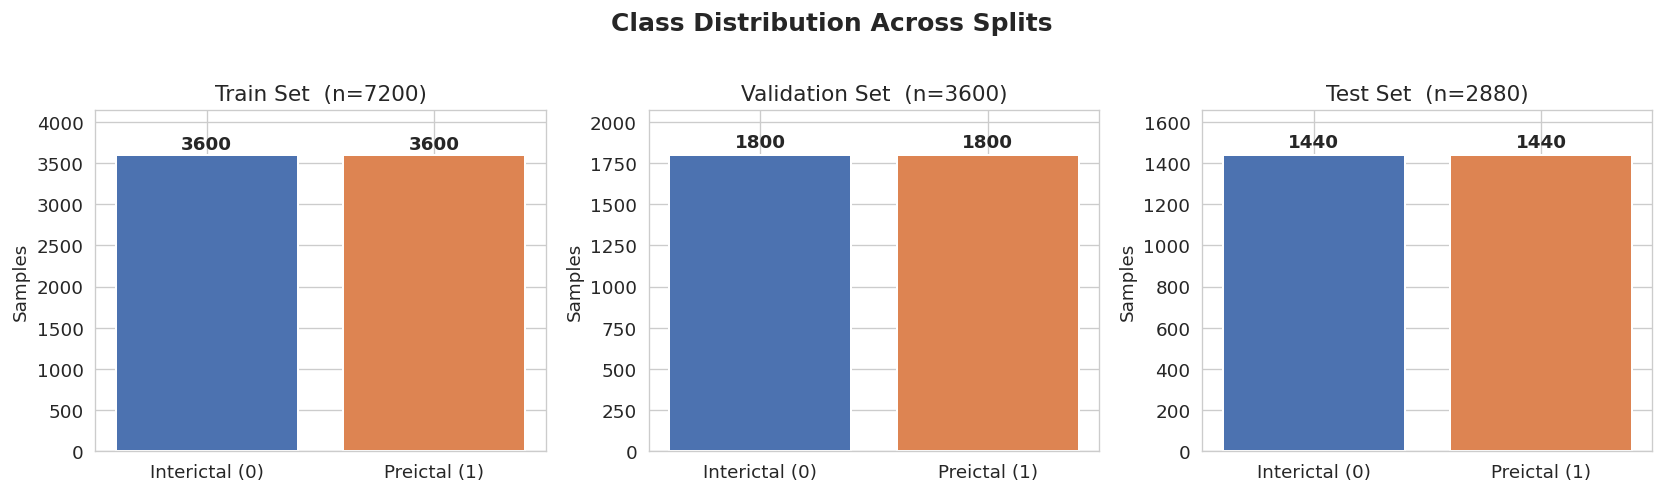


Window length : 5s × 256Hz = 1280 samples
Channels      : 20
Value range   : [-1.0965e-02, 1.0965e-02] V  (raw, unscaled)


In [3]:
splits = {'Train': y_train, 'Validation': y_valid, 'Test': y_test}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, y) in zip(axes, splits.items()):
    counts = pd.Series(y).value_counts().sort_index()
    bars = ax.bar(['Interictal (0)', 'Preictal (1)'], counts.values,
                  color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'{name} Set  (n={len(y)})', fontsize=13)
    ax.set_ylabel('Samples')
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle('Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nWindow length : {WIN_SEC}s × {FS}Hz = {N_SAMPLES} samples')
print(f'Channels      : {N_CH}')
print(f'Value range   : [{X_train.min():.4e}, {X_train.max():.4e}] V  (raw, unscaled)')

## 4. Raw EEG Signal Visualization

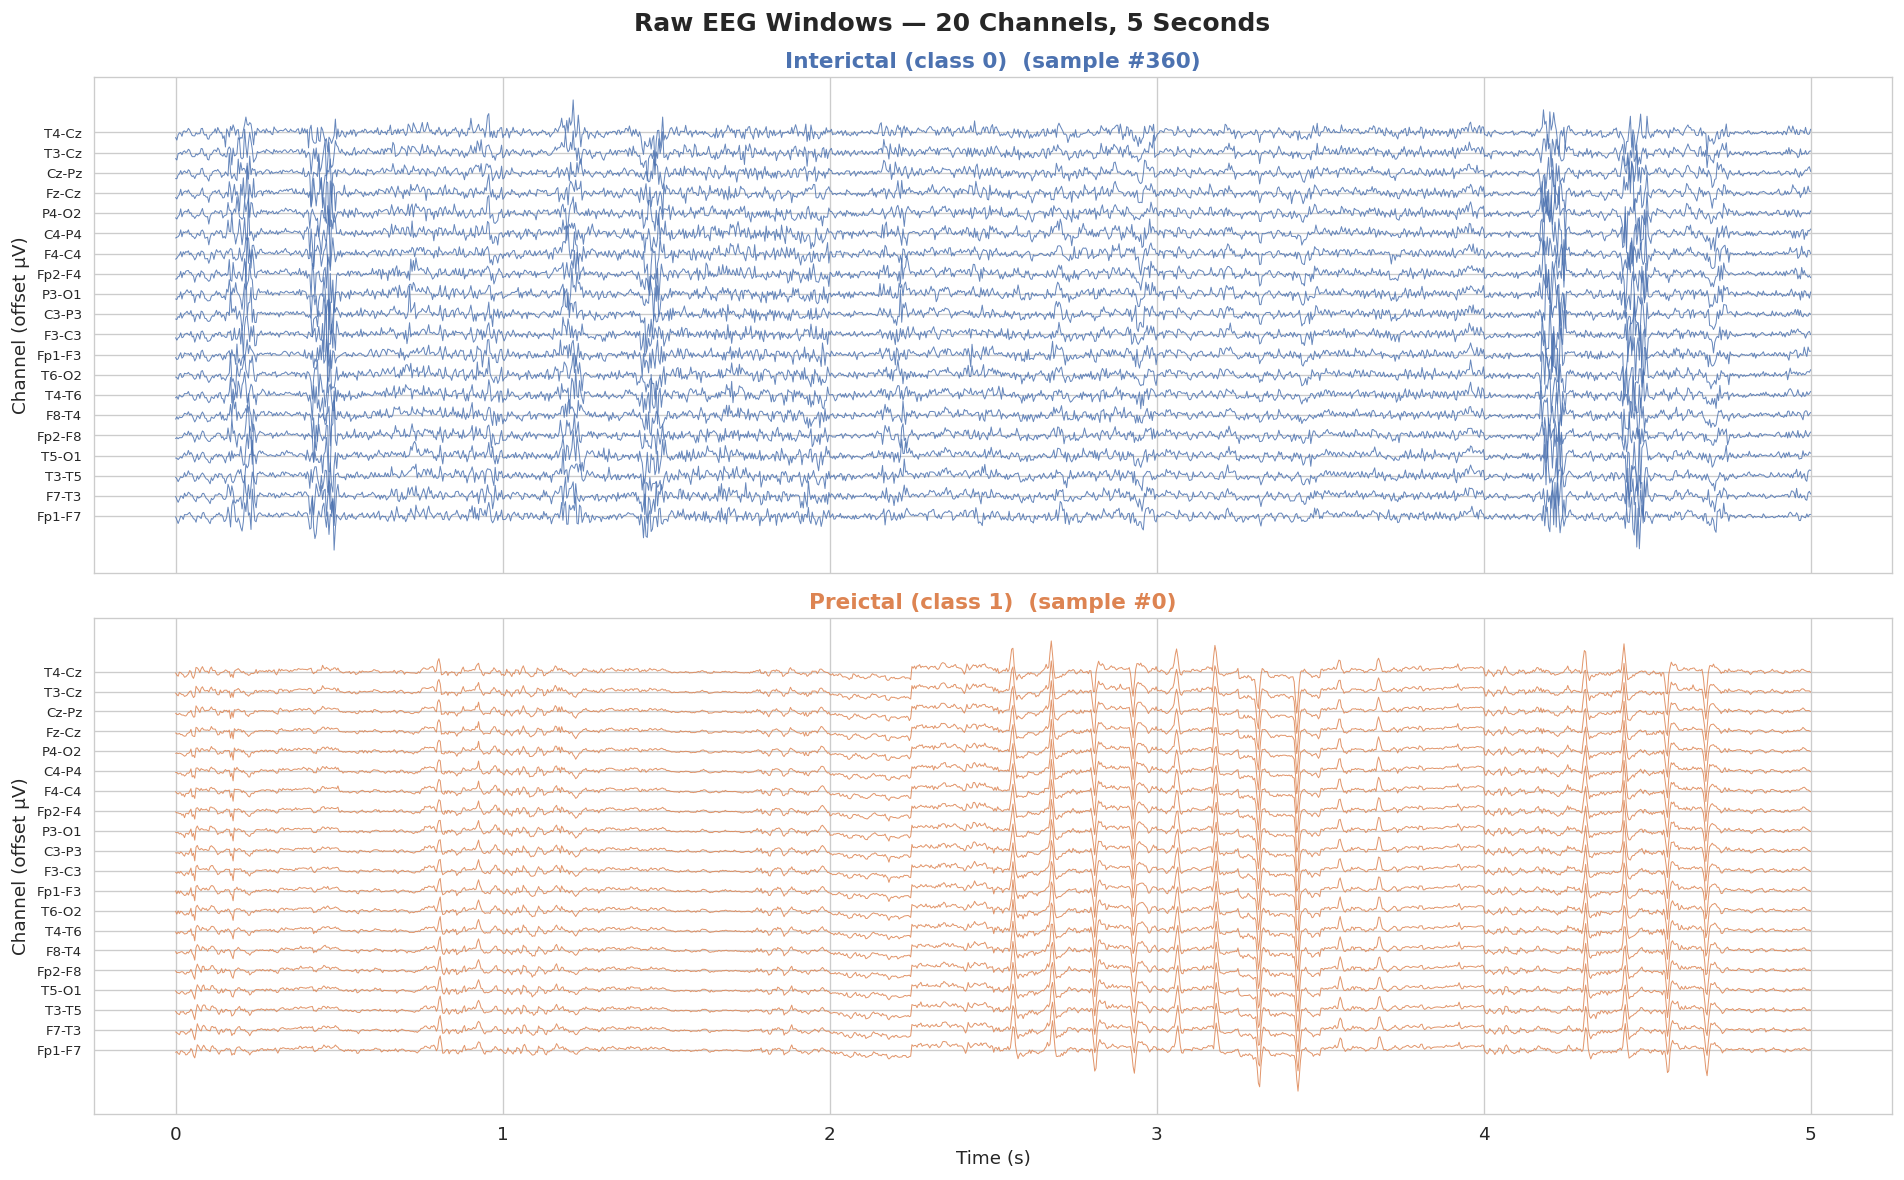

In [4]:
# Pick one interictal and one preictal example
np.random.seed(42)
idx_inter = np.where(y_train == 0)[0][0]
idx_preit = np.where(y_train == 1)[0][0]

t = np.linspace(0, WIN_SEC, N_SAMPLES)
scale = 1e6  # V → µV

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
for ax, idx, label, color in zip(
    axes,
    [idx_inter, idx_preit],
    ['Interictal (class 0)', 'Preictal (class 1)'],
    ['#4C72B0', '#DD8452']
):
    seg = X_train[idx] * scale   # (1280, 20)
    offset = np.arange(N_CH) * seg.std() * 4
    for ch in range(N_CH):
        ax.plot(t, seg[:, ch] + offset[ch], color=color, linewidth=0.6, alpha=0.85)
    ax.set_yticks(offset)
    ax.set_yticklabels(CH_NAMES, fontsize=8)
    ax.set_title(f'{label}  (sample #{idx})', fontsize=13, color=color, fontweight='bold')
    ax.set_ylabel('Channel (offset µV)')

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Raw EEG Windows — 20 Channels, 5 Seconds', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Amplitude Statistics

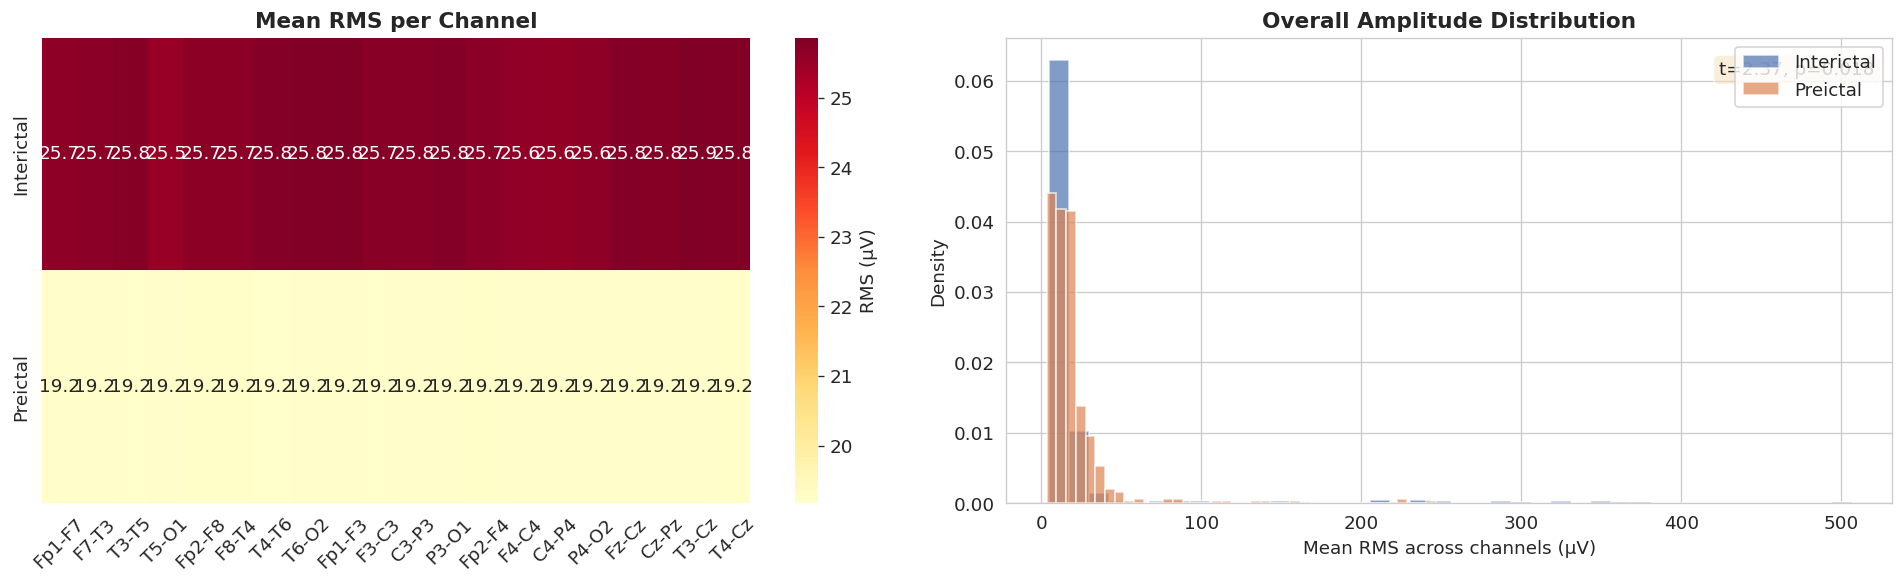

In [5]:
# Compute per-channel RMS for a subset of samples
N_SUBSET = 1000
idx0 = np.where(y_train == 0)[0][:N_SUBSET//2]
idx1 = np.where(y_train == 1)[0][:N_SUBSET//2]

# RMS per sample per channel  →  (N, 20)
rms0 = np.sqrt(np.mean(X_train[idx0]**2, axis=1)) * 1e6
rms1 = np.sqrt(np.mean(X_train[idx1]**2, axis=1)) * 1e6

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of mean RMS per channel
rms_df = pd.DataFrame(
    np.vstack([rms0.mean(axis=0), rms1.mean(axis=0)]),
    index=['Interictal', 'Preictal'],
    columns=CH_NAMES
)
sns.heatmap(rms_df, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.1f',
            cbar_kws={'label': 'RMS (µV)'})
axes[0].set_title('Mean RMS per Channel', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Distribution of overall RMS
axes[1].hist(rms0.mean(axis=1), bins=40, alpha=0.7, label='Interictal', color='#4C72B0', density=True)
axes[1].hist(rms1.mean(axis=1), bins=40, alpha=0.7, label='Preictal',   color='#DD8452', density=True)
axes[1].set_xlabel('Mean RMS across channels (µV)')
axes[1].set_ylabel('Density')
axes[1].set_title('Overall Amplitude Distribution', fontsize=13, fontweight='bold')
axes[1].legend()

t_stat, p_val = ttest_ind(rms0.mean(axis=1), rms1.mean(axis=1))
axes[1].text(0.98, 0.95, f't={t_stat:.2f}, p={p_val:.3f}',
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 6. Frequency Domain Analysis (Power Spectral Density)

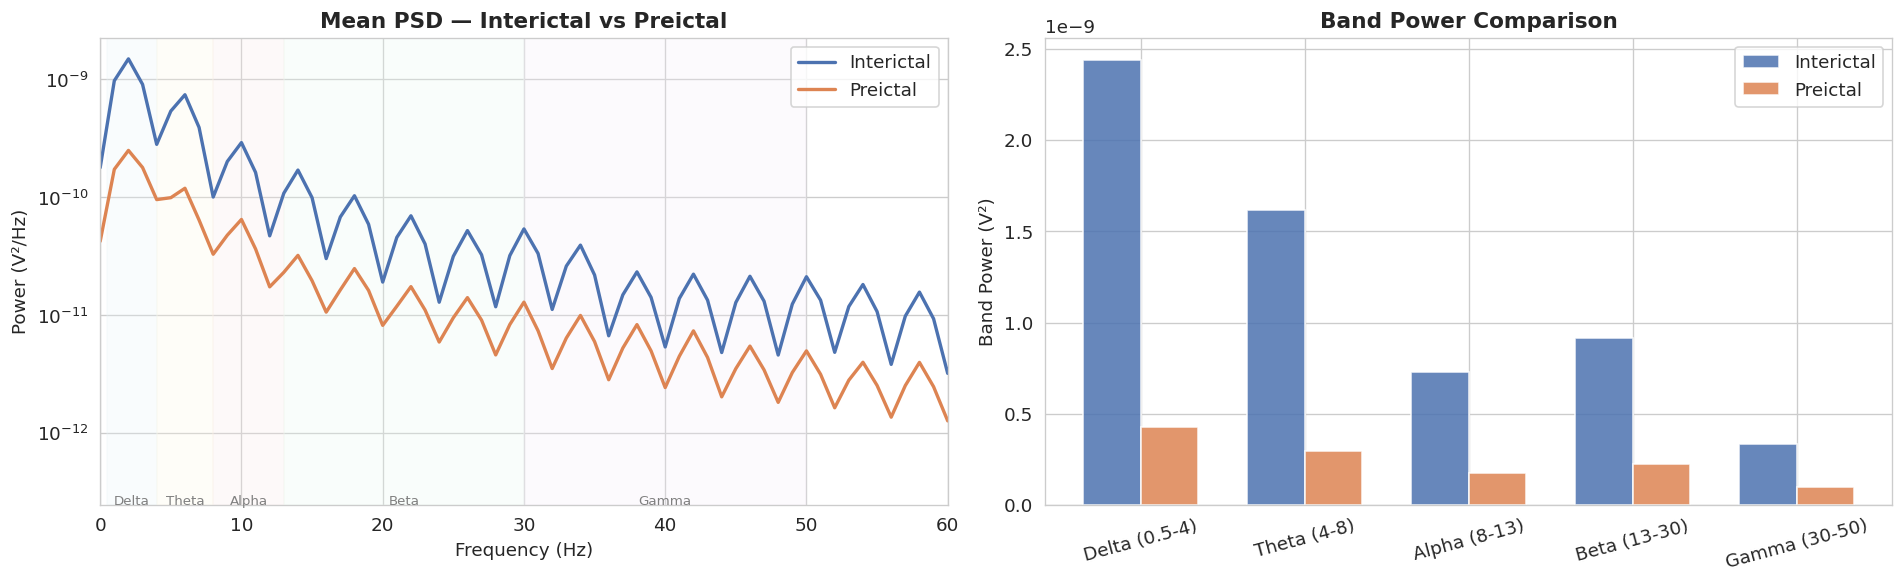

In [6]:
# Compute mean PSD across samples and channels for each class
def mean_psd(X_subset):
    psds = []
    for seg in X_subset:  # (1280, 20)
        for ch in range(N_CH):
            freqs, psd = signal.welch(seg[:, ch], fs=FS, nperseg=256)
            psds.append(psd)
    return freqs, np.array(psds).mean(axis=0)

N_PSD = 200
freqs, psd0 = mean_psd(X_train[idx0[:N_PSD]])
_,     psd1 = mean_psd(X_train[idx1[:N_PSD]])

# EEG frequency bands
bands = {
    'Delta\n(0.5-4)':  (0.5, 4),
    'Theta\n(4-8)':    (4, 8),
    'Alpha\n(8-13)':   (8, 13),
    'Beta\n(13-30)':   (13, 30),
    'Gamma\n(30-50)':  (30, 50),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full PSD plot (log scale)
ax = axes[0]
ax.semilogy(freqs, psd0, label='Interictal', color='#4C72B0', linewidth=2)
ax.semilogy(freqs, psd1, label='Preictal',   color='#DD8452', linewidth=2)
band_colors = ['#e8f4f8','#fef9e7','#f9ebea','#eafaf1','#f5eef8']
for (bname, (flo, fhi)), bc in zip(bands.items(), band_colors):
    ax.axvspan(flo, fhi, alpha=0.25, color=bc)
    ax.text((flo+fhi)/2, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-17,
            bname.split('\n')[0], ha='center', fontsize=8, color='gray')
ax.set_xlim(0, 60)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (V²/Hz)')
ax.set_title('Mean PSD — Interictal vs Preictal', fontsize=13, fontweight='bold')
ax.legend()

# Band power comparison
ax = axes[1]
def band_power(psd, freqs, flo, fhi):
    mask = (freqs >= flo) & (freqs < fhi)
    return np.trapz(psd[mask], freqs[mask])

bp0 = [band_power(psd0, freqs, flo, fhi) for _, (flo, fhi) in bands.items()]
bp1 = [band_power(psd1, freqs, flo, fhi) for _, (flo, fhi) in bands.items()]
bnames = [b.replace('\n', ' ') for b in bands.keys()]

x = np.arange(len(bnames))
w = 0.35
ax.bar(x - w/2, bp0, w, label='Interictal', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, bp1, w, label='Preictal',   color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bnames, rotation=15)
ax.set_ylabel('Band Power (V²)')
ax.set_title('Band Power Comparison', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 7. Per-Channel Band Power Heatmap

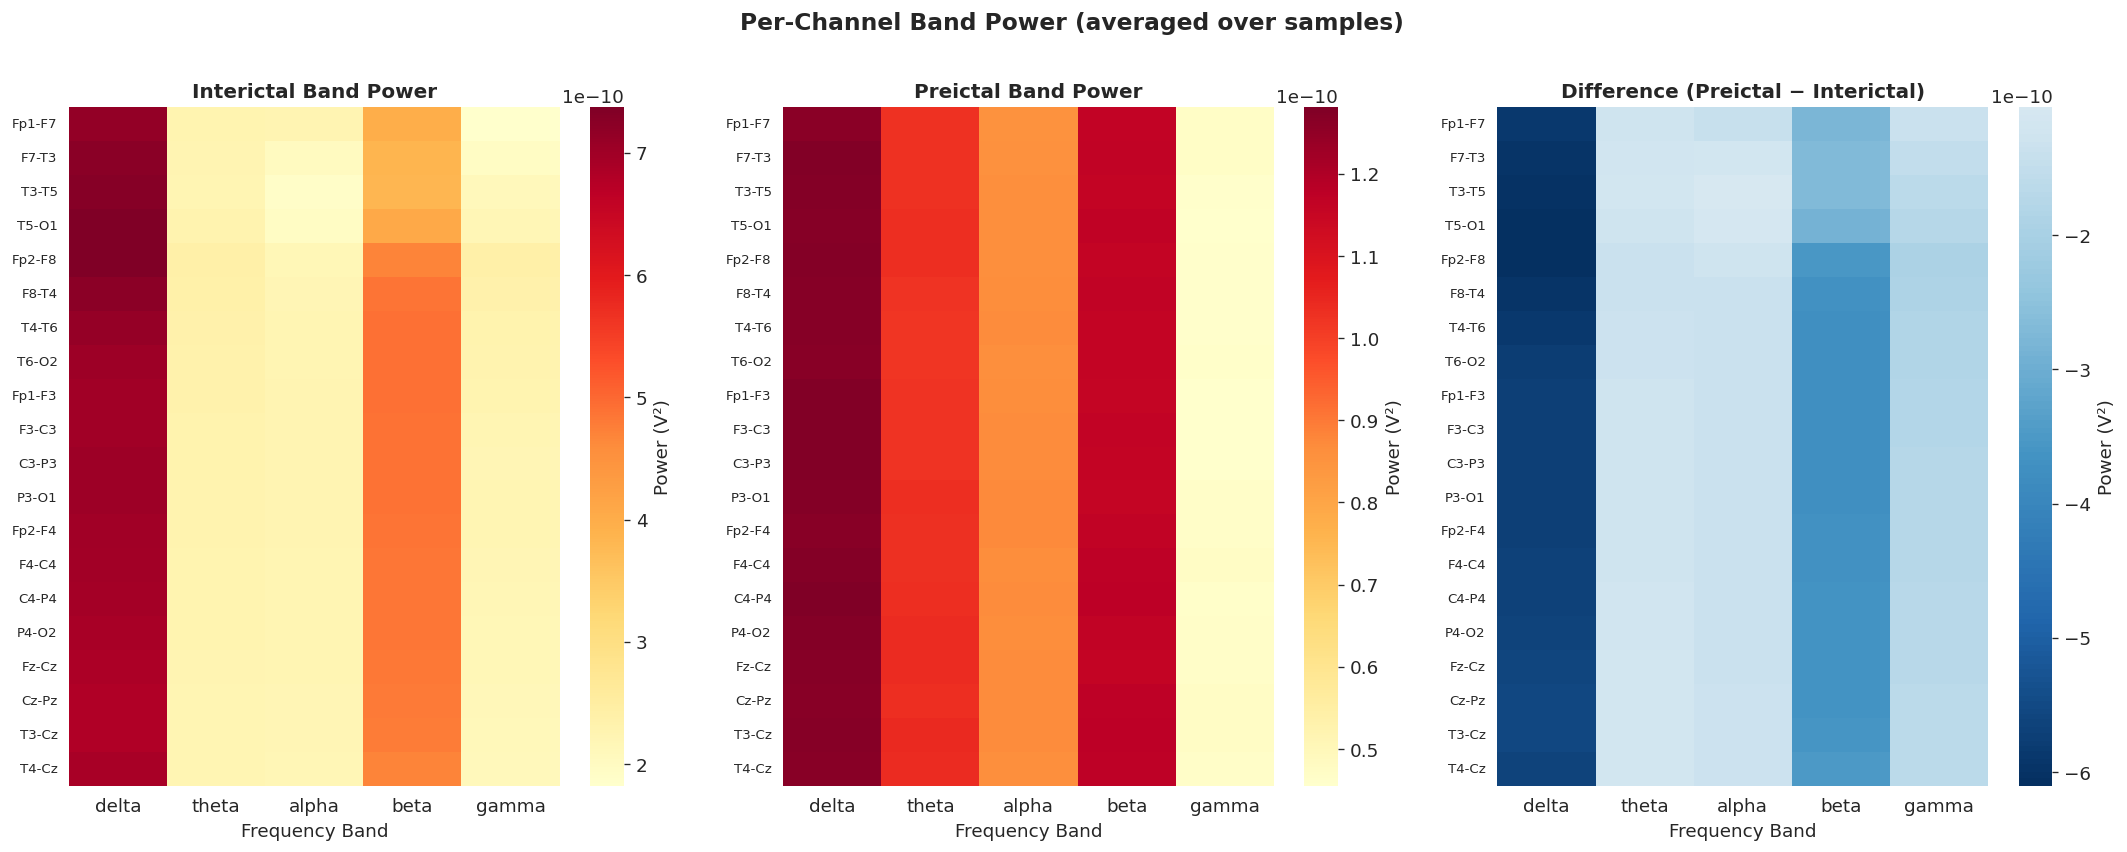

In [7]:
def channel_band_powers(X_subset, band_dict):
    """Returns (N_samples, N_channels * N_bands) feature matrix."""
    features = []
    for seg in X_subset:
        row = []
        for ch in range(N_CH):
            freqs_w, psd = signal.welch(seg[:, ch], fs=FS, nperseg=256)
            for flo, fhi in band_dict.values():
                mask = (freqs_w >= flo) & (freqs_w < fhi)
                row.append(np.trapz(psd[mask], freqs_w[mask]))
        features.append(row)
    return np.array(features)

bands_simple = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,50)}

N_VIZ = 100
bp_inter = channel_band_powers(X_train[idx0[:N_VIZ]], bands_simple).mean(axis=0).reshape(N_CH, 5)
bp_preit = channel_band_powers(X_train[idx1[:N_VIZ]], bands_simple).mean(axis=0).reshape(N_CH, 5)
bp_diff  = bp_preit - bp_inter

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, data, title in zip(
    axes,
    [bp_inter, bp_preit, bp_diff],
    ['Interictal Band Power', 'Preictal Band Power', 'Difference (Preictal − Interictal)']
):
    cmap = 'RdBu_r' if 'Diff' in title else 'YlOrRd'
    center = 0 if 'Diff' in title else None
    sns.heatmap(
        pd.DataFrame(data, index=CH_NAMES, columns=list(bands_simple.keys())),
        ax=ax, cmap=cmap, center=center, annot=False,
        cbar_kws={'label': 'Power (V²)'}
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency Band')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Per-Channel Band Power (averaged over samples)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Feature Extraction

In [8]:
def extract_features(X):
    """
    For each window (1280, 20) extract:
      - Time domain: mean, std, RMS, peak-to-peak  [4 × 20 = 80]
      - Freq domain: 5 band powers                 [5 × 20 = 100]
    Total: 180 features per window.
    """
    feats = []
    for seg in X:
        row = []
        for ch in range(N_CH):
            s = seg[:, ch]
            # time domain
            row += [s.mean(), s.std(), np.sqrt(np.mean(s**2)), s.max() - s.min()]
            # band power
            f_w, psd = signal.welch(s, fs=FS, nperseg=256)
            for flo, fhi in bands_simple.values():
                mask = (f_w >= flo) & (f_w < fhi)
                row.append(np.trapz(psd[mask], f_w[mask]))
        feats.append(row)
    return np.array(feats)

print('Extracting features...')
F_train = extract_features(X_train)
F_valid = extract_features(X_valid)
F_test  = extract_features(X_test)
print(f'Feature matrix shapes: train={F_train.shape}, valid={F_valid.shape}, test={F_test.shape}')

Extracting features...
Feature matrix shapes: train=(7200, 180), valid=(3600, 180), test=(2880, 180)


## 9. Feature Correlation & Importance Preview

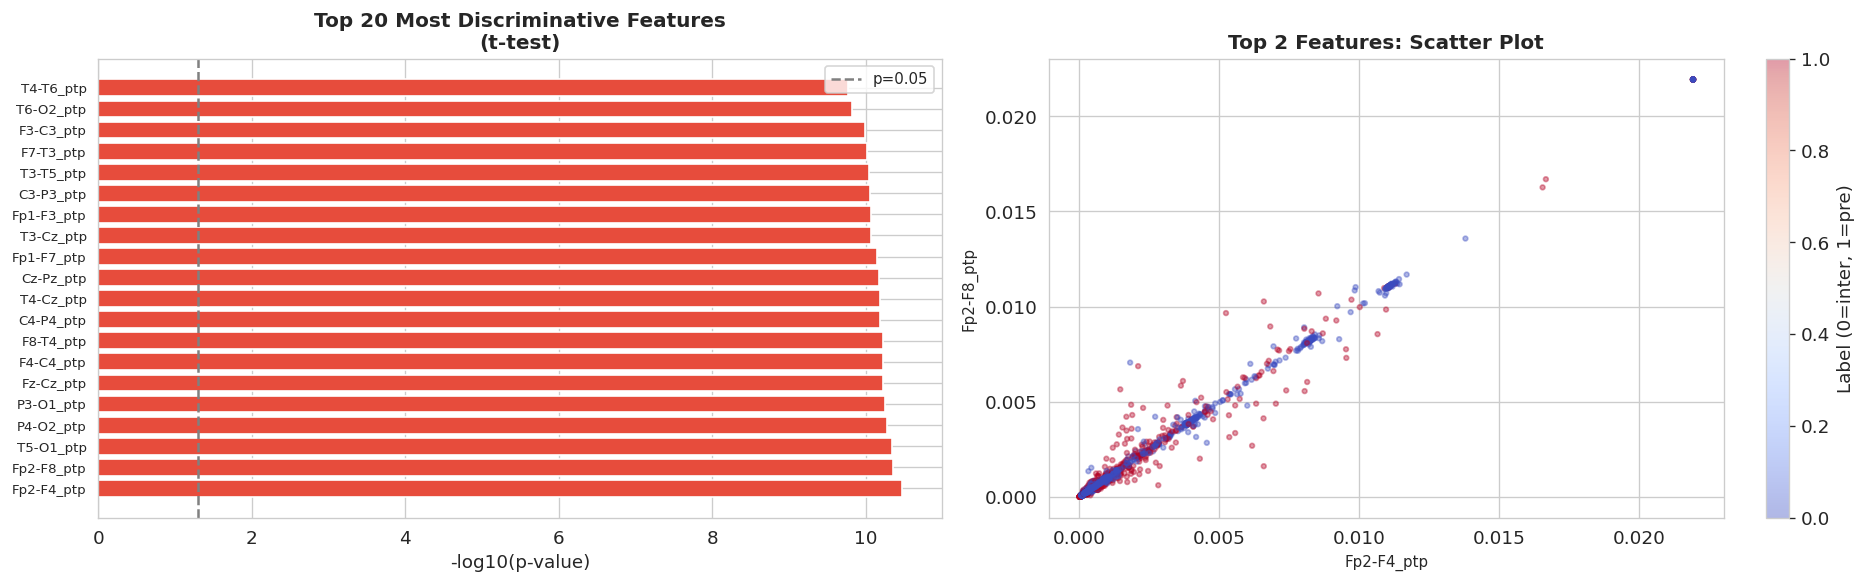

In [9]:
# Build tidy feature names
td_names = ['mean','std','rms','ptp']
bd_names = list(bands_simple.keys())
feat_names = []
for ch in CH_NAMES:
    for t in td_names:  feat_names.append(f'{ch}_{t}')
    for b in bd_names:  feat_names.append(f'{ch}_{b}')

feat_df = pd.DataFrame(F_train, columns=feat_names)
feat_df['label'] = y_train

# t-test p-values for each feature
from scipy.stats import ttest_ind
f0 = F_train[y_train == 0]
f1 = F_train[y_train == 1]
pvals = np.array([ttest_ind(f0[:, i], f1[:, i]).pvalue for i in range(F_train.shape[1])])
top20_idx = np.argsort(pvals)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top features by t-test p-value
ax = axes[0]
top_names = [feat_names[i] for i in top20_idx]
top_pvals = pvals[top20_idx]
colors = ['#e74c3c' if p < 0.001 else '#e67e22' if p < 0.01 else '#3498db' for p in top_pvals]
bars = ax.barh(range(20), -np.log10(top_pvals + 1e-300), color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels(top_names, fontsize=8)
ax.set_xlabel('-log10(p-value)')
ax.set_title('Top 20 Most Discriminative Features\n(t-test)', fontsize=12, fontweight='bold')
ax.axvline(-np.log10(0.05), color='gray', linestyle='--', label='p=0.05')
ax.legend(fontsize=9)

# Scatter of top 2 features
ax = axes[1]
f_a, f_b = top20_idx[0], top20_idx[1]
scatter = ax.scatter(
    F_train[:, f_a], F_train[:, f_b],
    c=y_train, cmap='coolwarm', alpha=0.4, s=8
)
plt.colorbar(scatter, ax=ax, label='Label (0=inter, 1=pre)')
ax.set_xlabel(feat_names[f_a], fontsize=9)
ax.set_ylabel(feat_names[f_b], fontsize=9)
ax.set_title('Top 2 Features: Scatter Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Classification

In [10]:
# Scale features
scaler = StandardScaler()
F_tr_sc = scaler.fit_transform(F_train)
F_vl_sc = scaler.transform(F_valid)
F_ts_sc = scaler.transform(F_test)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'LDA':                 LinearDiscriminantAnalysis(),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
print(f"{'Model':<22} {'Train AUC':>10} {'Val AUC':>10} {'Test AUC':>10} {'Test Acc':>10}")
print('-' * 65)

for name, clf in classifiers.items():
    clf.fit(F_tr_sc, y_train)
    proba_tr = clf.predict_proba(F_tr_sc)[:, 1]
    proba_vl = clf.predict_proba(F_vl_sc)[:, 1]
    proba_ts = clf.predict_proba(F_ts_sc)[:, 1]
    pred_ts  = clf.predict(F_ts_sc)

    auc_tr = roc_auc_score(y_train, proba_tr)
    auc_vl = roc_auc_score(y_valid, proba_vl)
    auc_ts = roc_auc_score(y_test,  proba_ts)
    acc_ts = accuracy_score(y_test, pred_ts)

    results[name] = {
        'clf': clf, 'proba_ts': proba_ts, 'pred_ts': pred_ts,
        'auc_tr': auc_tr, 'auc_vl': auc_vl, 'auc_ts': auc_ts, 'acc_ts': acc_ts
    }
    print(f"{name:<22} {auc_tr:>10.3f} {auc_vl:>10.3f} {auc_ts:>10.3f} {acc_ts:>10.3f}")

Model                   Train AUC    Val AUC   Test AUC   Test Acc
-----------------------------------------------------------------
Logistic Regression         0.617      0.612      0.577      0.546
LDA                         0.624      0.538      0.538      0.559
SVM (RBF)                   0.631      0.511      0.584      0.507
Random Forest               1.000      0.311      0.558      0.538
Gradient Boosting           0.940      0.301      0.561      0.575


## 11. Results Visualization

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ROC curves on test set
ax = axes[0]
colors_roc = ['#e74c3c','#2ecc71','#3498db','#9b59b6','#f39c12']
for (name, res), color in zip(results.items(), colors_roc):
    RocCurveDisplay.from_predictions(
        y_test, res['proba_ts'], name=f"{name} ({res['auc_ts']:.3f})",
        ax=ax, color=color
    )
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

# AUC bar chart
ax = axes[1]
names  = list(results.keys())
auc_tr = [results[n]['auc_tr'] for n in names]
auc_vl = [results[n]['auc_vl'] for n in names]
auc_ts = [results[n]['auc_ts'] for n in names]
x = np.arange(len(names))
w = 0.25
ax.bar(x - w, auc_tr, w, label='Train', color='#85c1e9', alpha=0.9)
ax.bar(x,     auc_vl, w, label='Valid', color='#82e0aa', alpha=0.9)
ax.bar(x + w, auc_ts, w, label='Test',  color='#f1948a', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.4, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance')
ax.set_title('AUC by Split & Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Best model confusion matrix
best_name = max(results, key=lambda n: results[n]['auc_ts'])
ax = axes[2]
ConfusionMatrixDisplay.from_predictions(
    y_test, results[best_name]['pred_ts'],
    display_labels=['Interictal', 'Preictal'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix\n{best_name} (best AUC={results[best_name]["auc_ts"]:.3f})',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Best Model: Detailed Report

In [ ]:
print(f'Best model: {best_name}\n')
print(classification_report(
    y_test, results[best_name]['pred_ts'],
    target_names=['Interictal (0)', 'Preictal (1)']
))

# Feature importances (for tree-based models)
if hasattr(results[best_name]['clf'], 'feature_importances_'):
    importances = results[best_name]['clf'].feature_importances_
    top_idx = np.argsort(importances)[::-1][:20]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(20), importances[top_idx], color='#3498db', alpha=0.85)
    ax.set_xticks(range(20))
    ax.set_xticklabels([feat_names[i] for i in top_idx], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Feature Importance')
    ax.set_title(f'Top 20 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 13. Summary

| | |
|---|---|
| **Benchmark** | 12 (SPH=30min, SOP=5min) |
| **Data** | 7200 train / 5400 valid / 2880 test windows |
| **Window** | 5s @ 256Hz, 20 channels |
| **Features** | 180 per window (80 time-domain + 100 band-power) |
| **Task** | Binary: preictal vs interictal |

**Next steps**:
- Try deep learning (CNN / LSTM) on raw `(1280, 20)` windows  
- Evaluate on all 12 benchmarks and compare  
- Explore patient-specific vs cross-patient models